In [1]:
%cd ../../..

/home/filip/Desktop/PINN-for-Simulating-2D-Incompressible-Fluid-Dynamics


In [2]:
import pathlib

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import torch
from torch import nn

from IPython.display import HTML, display
from pprint import pprint


import src.visuals as visual
import src.utils as utils

from src.models import PINN
from src.loss import NavierStokesLoss
from src.dataloader import load_data, gen_dataloaders
from src.train import train_model

In [3]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)


frac_size = 0.01

file_name = "data"
data_path = pathlib.Path(f"data/real_data/frac_{int(100*frac_size)}")

train_df, valid_df, test_df = load_data(data_path, file_name)

input_col_names = ['time', 're', 'x', 'y']
target_col_names = ['U_x', 'U_y', 'p']

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
train_df.describe()

,time,re,x,y,U_x,U_y,p
count,2364.000000,2364.000000,2364.000000,2364.000000,2364.000000,2364.000000,2364.000000
mean,5.037648,551.103284,0.502994,0.494534,-0.001159,0.002777,-0.012154
std,3.185588,267.209494,0.287947,0.288469,0.167034,0.120698,0.036133
min,0.000000,100.000000,0.007812,0.007812,-0.320640,-0.615746,-0.123937
25%,2.000000,338.775510,0.257812,0.242188,-0.056885,-0.007608,-0.021776
50%,5.000000,577.551020,0.507812,0.492188,-0.014541,0.002930,-0.002858
75%,8.000000,779.591837,0.757812,0.742188,0.000000,0.056842,0.000031
max,10.000000,1000.000000,0.992188,0.992188,0.938535,0.260186,0.589614


In [5]:
valid_df.describe()

,time,re,x,y,U_x,U_y,p
count,473.000000,473.000000,473.000000,473.000000,473.000000,473.000000,473.000000
mean,5.243129,570.755490,0.516566,0.520266,-0.003183,-0.001965,-0.013224
std,3.182660,258.227730,0.285342,0.278395,0.171800,0.130524,0.028415
min,0.000000,173.469388,0.007812,0.007812,-0.322576,-0.594661,-0.093894
25%,3.000000,302.040816,0.273438,0.304688,-0.061517,-0.015170,-0.023709
50%,5.000000,522.448980,0.523438,0.523438,-0.017427,0.001725,-0.005843
75%,8.000000,871.428571,0.773438,0.757812,0.000000,0.070115,0.000000
max,10.000000,926.530612,0.992188,0.992188,0.927724,0.248608,0.230252


In [6]:
test_df.describe()

,time,re,x,y,U_x,U_y,p
count,2163.00000,2163.000000,2163.000000,2163.000000,2163.000000,2163.000000,2163.000000
mean,5.01202,504.276940,0.502570,0.497329,0.008278,0.000318,-0.013503
std,3.16474,267.709836,0.280319,0.290292,0.186814,0.126550,0.036225
min,0.00000,118.367347,0.003906,0.003906,-0.339768,-0.617118,-0.200729
25%,2.00000,228.571429,0.269531,0.246094,-0.056772,-0.012578,-0.024611
50%,5.00000,430.612245,0.503906,0.496094,-0.016856,0.002101,-0.003399
75%,8.00000,853.061224,0.738281,0.738281,0.000000,0.057996,0.000106
max,10.00000,889.795918,0.996094,0.996094,0.960353,0.281834,0.608617


In [7]:
mean = train_df.mean()
std = train_df.std()

train_df = utils.normalize_data(train_df, mean, std)
valid_df = utils.normalize_data(valid_df, mean, std)
test_df = utils.normalize_data(test_df, mean, std)

In [8]:
train_dataloader, valid_dataloader, test_dataloader = gen_dataloaders(train_df, 
                                                                      valid_df, 
                                                                      test_df, 
                                                                      input_col_names, 
                                                                      target_col_names,
                                                                      32768)

In [9]:
model = PINN(len(input_col_names), len(target_col_names)).to(device)
criterion = NavierStokesLoss(1, mean, std)
optimizer = torch.optim.Adam(model.parameters())

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=15
)

EPOCHS = 500

In [10]:
n_param = sum([p.numel() for p in model.parameters()])

print("Number of parameters: ", n_param)

Number of parameters:  199427


In [11]:
run_dir = utils.create_run_directory(frac_size, label="cphys_1")

history = train_model(
    model,
    train_dataloader,
    valid_dataloader,
    criterion,
    optimizer,
    scheduler,
    device,
    EPOCHS,
    run_dir,
    checkpoint=None,
    physics_loss=True,
)

100%|██████████| 1/1 [00:00<00:00,  2.29it/s]


Epoch 0: train=0.989286 (data=0.989204, physics=0.000082) | valid=0.776451 (data=0.776063, physics=0.000388)


100%|██████████| 1/1 [00:00<00:00,  5.39it/s]


Epoch 1: train=0.849406 (data=0.849039, physics=0.000367) | valid=0.699730 (data=0.697899, physics=0.001830)


100%|██████████| 1/1 [00:00<00:00,  5.39it/s]


...

Epoch 497: train=0.032518 (data=0.024907, physics=0.007611) | valid=0.061499 (data=0.030326, physics=0.031173)


100%|██████████| 1/1 [00:00<00:00,  5.47it/s]


Epoch 498: train=0.032497 (data=0.024891, physics=0.007606) | valid=0.061500 (data=0.030314, physics=0.031187)


100%|██████████| 1/1 [00:00<00:00,  5.37it/s]


Epoch 499: train=0.032475 (data=0.024875, physics=0.007600) | valid=0.061501 (data=0.030307, physics=0.031194)


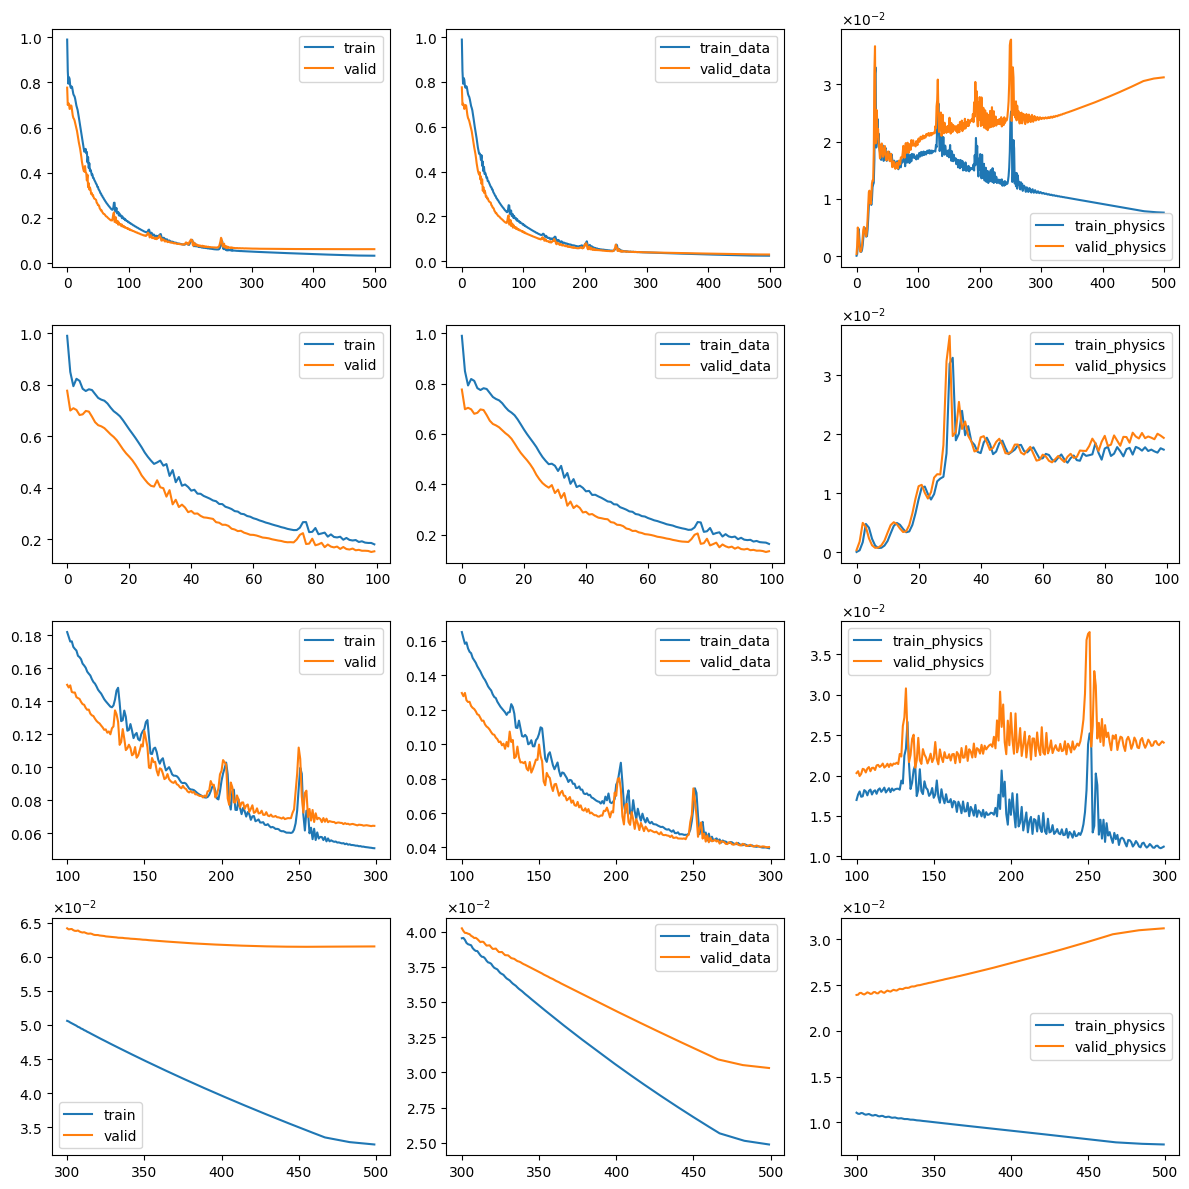

In [12]:
def plot(df, ax):
    for x in ax:
        x.ticklabel_format(axis='y', style='sci', scilimits=(-2,2), useMathText=True)

    df[["train", "valid"]].plot(ax=ax[0])
    df[["train_data", "valid_data"]].plot(ax=ax[1])
    df[["train_physics", "valid_physics"]].plot(ax=ax[2])
    
history_df = pd.DataFrame(history)

fig, ax = plt.subplots(4, 3, figsize=(12, 12), tight_layout=True)

plot(history_df, ax[0])
plot(history_df[:100], ax[1])
plot(history_df[100:300], ax[2])
plot(history_df[300:], ax[3])

fig.savefig(run_dir / "losses.png")
history_df.to_csv(run_dir / "losess.csv")